# Exploratory Data Analysis – Olympics Dataset

The purpose of this analysis is to explore historical data from the **Olympic Games** to understand the dataset’s structure, content, and potential patterns. This analysis will serve as the foundation for further visualizations and the dashboard.

## Uppgift 0 (Warm-up): 

Perform exploratory data analysis (EDA) on the dataset: examine countries, sports, medal types, and age statistics, and create visualizations like gender distribution and top 10 countries by medals.

In [1]:
# a) b)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "../data/athlete_events.csv" # File path to dataset
file_path1= "../data/noc_regions.csv"   # file path for noc regions
# Read the CSV file
df = pd.read_csv(file_path) # dataset for athlete
noc= pd.read_csv(file_path1) # NOC codes -> country mapping
print(df.columns) # show the columns in athelet dataframe
print(noc.columns) # show the columns in noc datframe
# Show first five rows
display(df.head())  
display(noc.head()) 
# Merge the two data frames 
merged = df.merge(noc, on="NOC", how="left")
# Get unique NOC codes and sort them alphabetically
countries_list = sorted(df['NOC'].unique())
# show countries with the Olympic Games as a dataframe
display(pd.DataFrame(countries_list, columns=["NOC"]))
# Print total number of countries
print(f"Total number of countries: {len(countries_list)}")
merged.head() # se the data frame after merge

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')
Index(['NOC', 'region', 'notes'], dtype='object')


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


,NOC
0,AFG
1,AHO
2,ALB
3,ALG
4,AND
...,...
225,YEM
226,YMD
227,YUG
228,ZAM


Total number of countries: 230


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [2]:
# c)
sporter= df['Sport'].unique() # bring all unique sport
print(f"Sports in the Olympic are : {sporter}")
count= len(sporter) # count the number of sports
print(f"Number Of Sports is : {count}")

Sports in the Olympic are : ['Basketball' 'Judo' 'Football' 'Tug-Of-War' 'Speed Skating'
 'Cross Country Skiing' 'Athletics' 'Ice Hockey' 'Swimming' 'Badminton'
 'Sailing' 'Biathlon' 'Gymnastics' 'Art Competitions' 'Alpine Skiing'
 'Handball' 'Weightlifting' 'Wrestling' 'Luge' 'Water Polo' 'Hockey'
 'Rowing' 'Bobsleigh' 'Fencing' 'Equestrianism' 'Shooting' 'Boxing'
 'Taekwondo' 'Cycling' 'Diving' 'Canoeing' 'Tennis' 'Modern Pentathlon'
 'Figure Skating' 'Golf' 'Softball' 'Archery' 'Volleyball'
 'Synchronized Swimming' 'Table Tennis' 'Nordic Combined' 'Baseball'
 'Rhythmic Gymnastics' 'Freestyle Skiing' 'Rugby Sevens' 'Trampolining'
 'Beach Volleyball' 'Triathlon' 'Ski Jumping' 'Curling' 'Snowboarding'
 'Rugby' 'Short Track Speed Skating' 'Skeleton' 'Lacrosse' 'Polo'
 'Cricket' 'Racquets' 'Motorboating' 'Military Ski Patrol' 'Croquet'
 'Jeu De Paume' 'Roque' 'Alpinism' 'Basque Pelota' 'Aeronautics']
Number Of Sports is : 66


In [3]:
# d)
medal= df['Medal'].dropna().unique()  # Get all unique medal types, ignoring missing values
print(f" medal types {medal}")

 medal types ['Gold' 'Bronze' 'Silver']


In [4]:
# e)
# Drop missing values first
age_data = df['Age'].dropna()

# Use agg() to calculate multiple statistics
age_stats = age_data.agg(['mean', 'median', 'min', 'max', 'std'])
print(f"Statistic for Age : \n{age_stats}")


Statistic for Age : 
mean      25.556898
median    24.000000
min       10.000000
max       97.000000
std        6.393561
Name: Age, dtype: float64


After performing the general exploratory data analysis (EDA) on the Olympic dataset, we further explore the data with **our own questions** to gain deeper insights into patterns, trends, and interesting facts.<br>
### Age-related analysis
- Who are the youngest and oldest medal-winning athletes?

In [5]:
# f)
# Filter only athletes who won medals
medalists = merged.dropna(subset=['Medal'])
# Youngest and oldest medal winners
youngest = medalists['Age'].min()
oldest = medalists['Age'].max()

print(f"Youngest medal winner: {youngest} years old")
print(f"Oldest medal winner: {oldest} years old")


Youngest medal winner: 10.0 years old
Oldest medal winner: 73.0 years old


- Average age by medal type **(Gold, Silver, Bronze)**

In [6]:
avg_age_by_medal = medalists.groupby('Medal')['Age'].mean()
print(avg_age_by_medal)

Medal
Bronze    25.879210
Gold      25.901013
Silver    25.996724
Name: Age, dtype: float64


## Gender analysis



The number of male and female in the Olympic: Sex
M    196594
F     74522
Name: count, dtype: int64
Male-to-female ratio: 2.64


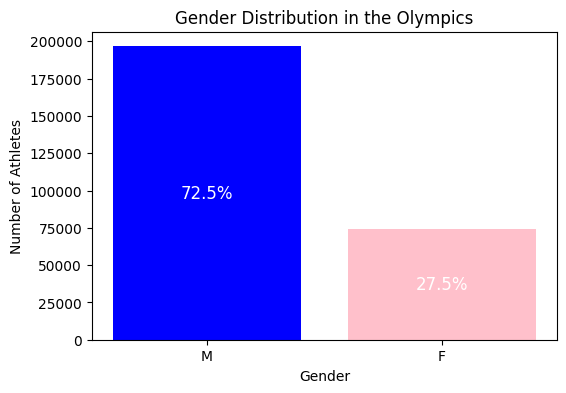

In [7]:
# g) Gender distribuation
counts=df['Sex'].value_counts() # count male and female
total = counts.sum()  # total number of athletes
print(f"The number of male and female in the Olympic: {counts}")
male_to_female_ratio = counts['M'] / counts['F'] # calcuate the ratio M/F
print(f"Male-to-female ratio: {male_to_female_ratio:.2f}")
# Plot #g)

fig, ax = plt.subplots(figsize=(6,4))
bars=plt.bar(counts.index, counts.values ,color=['blue', 'pink'])
plt.title("Gender Distribution in the Olympics")
plt.ylabel("Number of Athletes")
plt.xlabel("Gender")

for i, bar in enumerate(bars):
    height = bar.get_height()
    percent = height / total * 100
    ax.text(
        i,            # just use the index for x-position
        height / 2,   # y-position in middle of bar
        f'{percent:.1f}%',
        ha='center',
        va='center',
        color='white',
        fontsize=12
    )

The data shows that the number of male athletes is **2.64** the number of female athletes.
This means men participated in the Olympics at a much higher rate compared to women.


## Gender Participation Over Time 

Sex,F,M
Year,,
1896,0,380
1900,33,1903
1904,16,1285
1906,11,1722
1908,47,3054
1912,87,3953
1920,134,4158
1924,261,5432
1928,437,5137


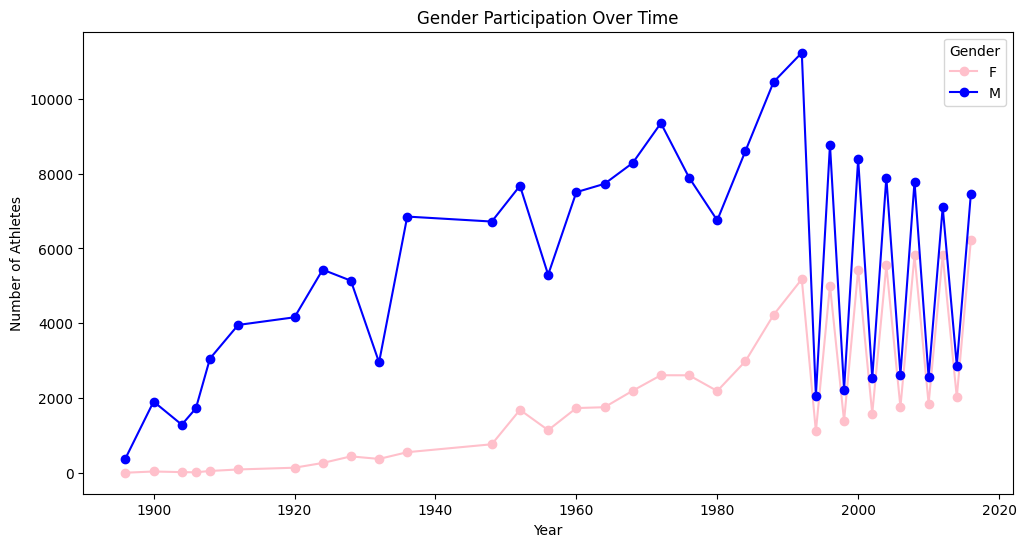

In [8]:
# Group the dataset by 'Year' and 'Sex', then count the number of athletes in each group
# Moves the second level of the index (Sex) into columns.(unstack)
gender_year = df.groupby(['Year', 'Sex']).size().unstack(fill_value=0)
gender_year.plot(figsize=(12,6) , marker='o', color=['pink', 'blue'])
plt.title("Gender Participation Over Time") # Adds a descriptive title to the chart
plt.ylabel("Number of Athletes") # set the label for Y-axies
plt.xlabel("Year") # set the label for X-Axies
plt.legend(title="Gender")
gender_year

The plot shows Olympic participation by gender across the years. Although **men have generally outnumbered women**, the number of female athletes has grown consistently, reflecting greater inclusion and opportunities for women in the Games.

---------

Season,Summer,Winter
Year,,
1896,380,0
1900,1936,0
1904,1301,0
1906,1733,0
1908,3101,0
1912,4040,0
1920,4292,0
1924,5233,460
1928,4992,582


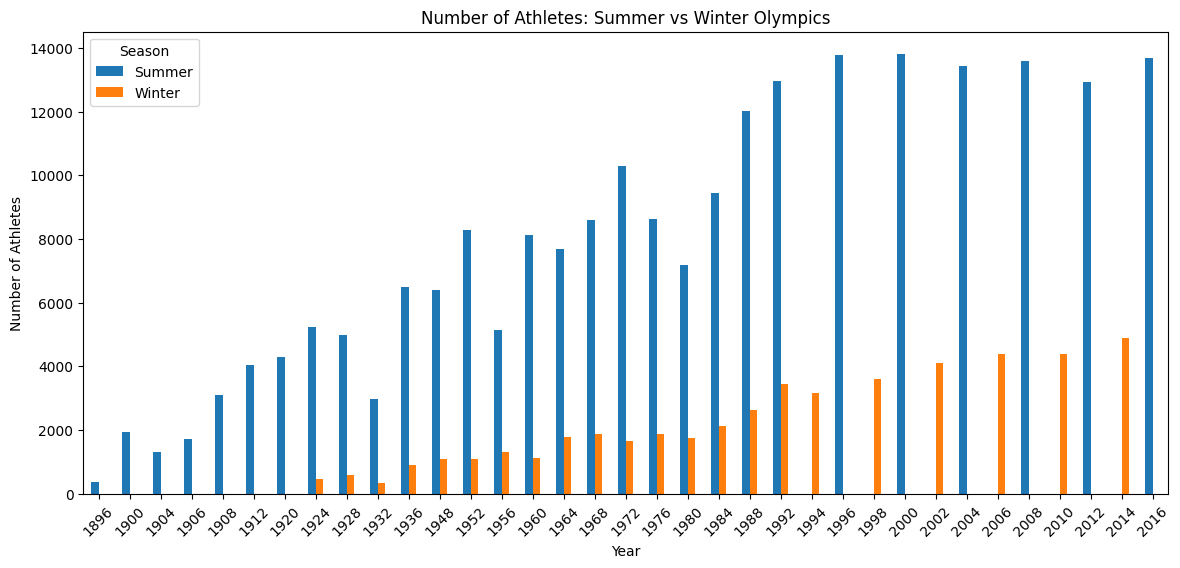

In [9]:
# Group by Year and Season, count total athletes
athletes_per_year = df.groupby(['Year','Season']).size().unstack('Season', fill_value=0)

# Plot grouped bar chart
athletes_per_year.plot(kind='bar', figsize=(14,6))
plt.title("Number of Athletes: Summer vs Winter Olympics")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.xticks(rotation=45)
plt.legend(title="Season")
athletes_per_year

The chart shows the number of athletes in each Olympic year for **Summer** and **Winter** Games. Summer Olympics consistently have more participants than Winter, and overall participation has grown over time. 

----------

- Medal Distribution by Gender

In [10]:
# Count medals by gender
medal_counts = medalists['Sex'].value_counts()
print(medal_counts)



Sex
M    28530
F    11253
Name: count, dtype: int64


- Sport Preferences by Gender

In [11]:
# Count the number of athletes in each sport and sort them in descending order
count_sport=df['Sport'].value_counts()
print(count_sport)
# create a table showing number of athletes per sport by gender.
sport_gender = df.groupby(['Sport', 'Sex']).size().unstack(fill_value=0)
#print(sport_gender.shape)
display(sport_gender.head())
# Find sport with most males
sport_most_male = sport_gender['M'].idxmax()   # sport name
male_count = sport_gender['M'].max()          # number of male athletes
print(f"Sport with the most male athletes: {sport_most_male} ({male_count} males)")
# Find sport with most females
sport_most_female = sport_gender['F'].idxmax()   # sport name
female_count = sport_gender['F'].max()           # number of female athletes
print(f"Sport with the most female athletes: {sport_most_female} ({female_count} females)")



Sport
Athletics        38624
Gymnastics       26707
Swimming         23195
Shooting         11448
Cycling          10859
                 ...  
Racquets            12
Jeu De Paume        11
Roque                4
Basque Pelota        2
Aeronautics          1
Name: count, Length: 66, dtype: int64


Sex,F,M
Sport,,
Aeronautics,0,1
Alpine Skiing,3398,5431
Alpinism,1,24
Archery,1015,1319
Art Competitions,377,3201


Sport with the most male athletes: Athletics (26958 males)
Sport with the most female athletes: Athletics (11666 females)


- Total number of athletes varies widely across sports (from 1 in Aeronautics to 38,624 in Athletics).

- The table shows the number of male **(M)** and female **(F)** athletes in each sport.

- Athletics has the most male athletes **(26,958)** and most female athletes **(11,666)**.

Text(0.5, 1.0, 'Medal Distribution by Gender')

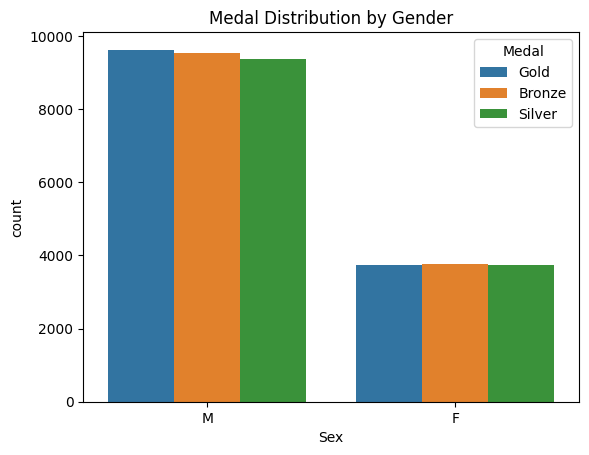

In [12]:
# Create a bar chart counting the number of medalists for each gender
sns.countplot(x='Sex', hue='Medal', data=medalists)
# set title to the plot
plt.title("Medal Distribution by Gender")


We notice that **male athletes have won more medals** compared to female athletes.
This is also related to the fact that the number of male athletes is **2.64** times the number of female athletes, meaning male participation is significantly higher.The distribution of medal types is almost the same between males and females, suggesting that the proportion of Gold, Silver, and Bronze medals is similar across genders.

--------

## Countries analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'USA'),
  Text(1, 0, 'Russia'),
  Text(2, 0, 'Germany'),
  Text(3, 0, 'UK'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Italy'),
  Text(6, 0, 'Sweden'),
  Text(7, 0, 'Canada'),
  Text(8, 0, 'Australia'),
  Text(9, 0, 'Hungary')])

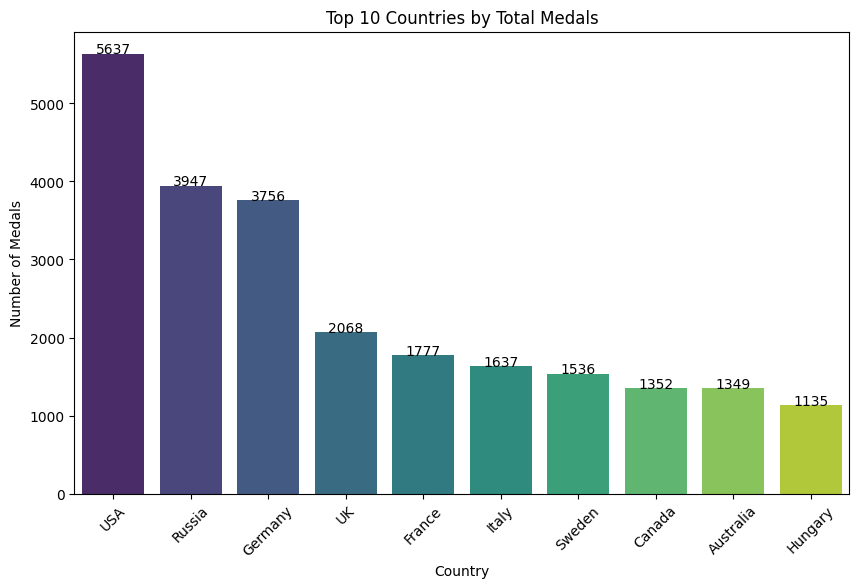

In [13]:
# h)
# Top 10 countries by total medals
top_countries = (
    medalists.groupby('region').size()
   .sort_values(ascending=False)
   .head(10).reset_index(name='Medals')
)
# Create barplot
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_countries,
    x='region',
    y='Medals',
    palette="viridis", 
    hue='region'
)

# Add numbers on top of bars
for index, row in top_countries.iterrows(): #Loops through each row of top_countries
    plt.text(index, row.Medals, row.Medals, ha='center') #places a text label on top of each ba

# Labels and title
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.title("Top 10 Countries by Total Medals")
plt.xticks(rotation=45)



The bar chart shows the top 10 countries with the highest number of medals in the historical Olympic dataset. The **United States (USA)** is clearly the most dominant nation, followed by countries like **Russia (RUS)**, **Germany (GER)**. The large difference in bar heights reflects long-term dominance by these nations in Olympic competitions.

----------
---------

## Uppgift 1 (Country Statistics):

Anonymize athlete names and analyze **Great Britain**  Olympic performance with medal counts, age distribution, and key visualization

#### ***Anonymization and Focus on Great Britain***

To protect athlete privacy, we **anonymized** all athlete names using the **SHA-256** hash function. This creates unique, irreversible identifiers for each athlete, allowing us to analyze the data without exposing personal information.

In [14]:
import hashlib as hl

# Filter for Great Britain
gbr = merged[merged['NOC'] == 'GBR'].reset_index(drop=True)
# show first five rows
gbr.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,453,Leslie Ablett,M,24.0,NaN,NaN,Great Britain,GBR,1928 Summer,1928,Summer,Amsterdam,Water Polo,Water Polo Men's Water Polo,NaN,UK,NaN
1,453,Leslie Ablett,M,32.0,NaN,NaN,Great Britain,GBR,1936 Summer,1936,Summer,Berlin,Water Polo,Water Polo Men's Water Polo,NaN,UK,NaN
2,509,Gary Abraham,M,17.0,175.0,64.0,Great Britain,GBR,1976 Summer,1976,Summer,Montreal,Swimming,Swimming Men's 100 metres Backstroke,NaN,UK,NaN
3,509,Gary Abraham,M,17.0,175.0,64.0,Great Britain,GBR,1976 Summer,1976,Summer,Montreal,Swimming,Swimming Men's 4 x 100 metres Medley Relay,NaN,UK,NaN
4,509,Gary Abraham,M,21.0,175.0,64.0,Great Britain,GBR,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Backstroke,NaN,UK,NaN


In [15]:
gbr["Name"] = gbr["Name"].astype(str) # Make sure Name column values are string
hashes = gbr["Name"].apply(lambda x: hl.sha256(x.encode()).hexdigest()) # Apply SHA-256 hash to each Name
hashes.head() # show first five names after applaying sha256 function

0    068d40aa50057f323cccc9b76161d21e3014635a0bd3b4...
1    068d40aa50057f323cccc9b76161d21e3014635a0bd3b4...
2    ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...
3    ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...
4    ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...
Name: Name, dtype: object

In [16]:
gbr.insert(2, "Hash values", hashes) # insert hash values to the data frame *gbr* on the position 2
gbr.head() # show first five rows after anonymizing

,ID,Name,Hash values,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,453,Leslie Ablett,068d40aa50057f323cccc9b76161d21e3014635a0bd3b4...,M,24.0,NaN,NaN,Great Britain,GBR,1928 Summer,1928,Summer,Amsterdam,Water Polo,Water Polo Men's Water Polo,NaN,UK,NaN
1,453,Leslie Ablett,068d40aa50057f323cccc9b76161d21e3014635a0bd3b4...,M,32.0,NaN,NaN,Great Britain,GBR,1936 Summer,1936,Summer,Berlin,Water Polo,Water Polo Men's Water Polo,NaN,UK,NaN
2,509,Gary Abraham,ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...,M,17.0,175.0,64.0,Great Britain,GBR,1976 Summer,1976,Summer,Montreal,Swimming,Swimming Men's 100 metres Backstroke,NaN,UK,NaN
3,509,Gary Abraham,ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...,M,17.0,175.0,64.0,Great Britain,GBR,1976 Summer,1976,Summer,Montreal,Swimming,Swimming Men's 4 x 100 metres Medley Relay,NaN,UK,NaN
4,509,Gary Abraham,ad4b525a32fc54f54d6221545f27ff31d81200fa3bc741...,M,21.0,175.0,64.0,Great Britain,GBR,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Backstroke,NaN,UK,NaN


### ***Analysis — Sports where Great Britain won the most medals***

In [17]:
gbr_medals= gbr.dropna(subset='Medal') # Keep only rows where Medal is not NaN
# Group by Sport and count number of medals
medals_per_sport = gbr_medals.groupby('Sport')['Medal'].size().sort_values(ascending=False)
print(f" Number of sports that they got Medal in : {medals_per_sport.size}") # count sports
print(f" Sports  and thier number of medal :\n {medals_per_sport} ") # show Sports


 Number of sports that they got Medal in : 44
 Sports  and thier number of medal :
 Sport
Athletics                    338
Rowing                       270
Cycling                      182
Hockey                       163
Sailing                      143
Swimming                     127
Shooting                      99
Equestrianism                 83
Tennis                        67
Boxing                        56
Gymnastics                    51
Football                      45
Tug-Of-War                    40
Rugby                         30
Polo                          30
Fencing                       28
Water Polo                    28
Canoeing                      22
Ice Hockey                    22
Cricket                       21
Figure Skating                20
Judo                          19
Curling                       17
Wrestling                     17
Bobsleigh                     14
Archery                       13
Diving                        13
Alpinism           

### Visualization

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Athletics'),
  Text(1, 0, 'Rowing'),
  Text(2, 0, 'Cycling'),
  Text(3, 0, 'Hockey'),
  Text(4, 0, 'Sailing'),
  Text(5, 0, 'Swimming'),
  Text(6, 0, 'Shooting'),
  Text(7, 0, 'Equestrianism'),
  Text(8, 0, 'Tennis'),
  Text(9, 0, 'Boxing')])

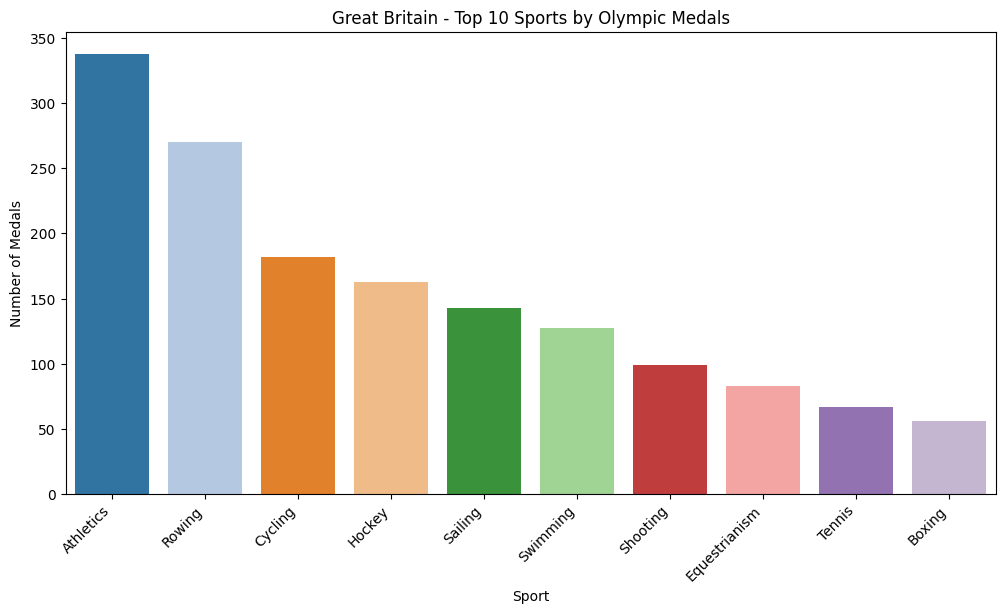

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(x=medals_per_sport.head(10).index, 
            y=medals_per_sport.head(10).values, 
            palette='tab20',
            hue=medals_per_sport.head(10).index)
plt.title("Great Britain - Top 10 Sports by Olympic Medals")
plt.xlabel("Sport")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45, ha='right')

### Bar Chart Analysis – Top Sports by Medals

Great Britain has been most successful in **Athletics**, followed by **Rowing** and **Cycling**. Other top sports include Hockey, Sailing, Swimming, Shooting, Equestrianism, Tennis, and Boxing. This shows that the country’s Olympic strengths are concentrated in endurance, skill, and precision-based sports.

-------

In [19]:
# Take top 10 sports by total medals
top10_sports = medals_per_sport.head(10).index

# Filter the original medal DataFrame for only these sports
top10_medals = gbr_medals[gbr_medals['Sport'].isin(top10_sports)]

# Group by Sport and Medal type, then unstack
top_medal = top10_medals.groupby(['Sport', 'Medal']).size().unstack(fill_value=0)
top_medal['total'] = top_medal.sum(axis=1)
sorted_top_medal=top_medal.sort_values(by='total', ascending= False)
sorted_top_medal

Medal,Bronze,Gold,Silver,total
Sport,,,,
Athletics,127,78,133,338
Rowing,42,109,119,270
Cycling,55,59,68,182
Hockey,82,57,24,163
Sailing,24,71,48,143
Swimming,55,23,49,127
Shooting,34,29,36,99
Equestrianism,23,26,34,83
Tennis,19,25,23,67


### Visualization

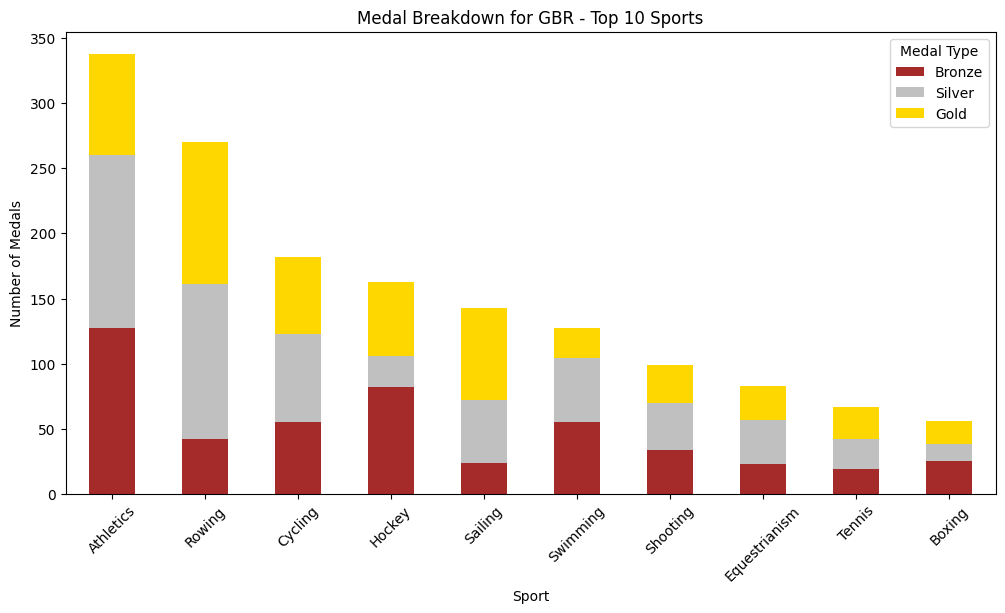

In [20]:
colors = ['brown', 'silver', 'gold']  # Bronze, Silver, Gold

# Plot stacked bar chart 
sorted_top_medal[['Bronze', 'Silver', 'Gold']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=colors)

plt.title("Medal Breakdown for GBR - Top 10 Sports")
plt.xlabel("Sport")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.legend(title="Medal Type")

### **Pie Chart of medal types:**

Text(0.5, 1.0, 'Medal Types Distribution (GBR)')

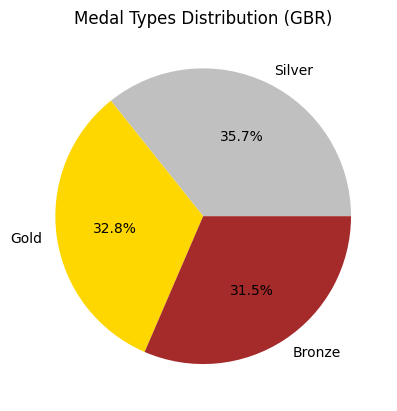

In [48]:
total_medals = gbr_medals['Medal'].value_counts()
plt.pie(total_medals, labels=total_medals.index, autopct='%1.1f%%', colors=['silver','gold','brown'])
plt.title("Medal Types Distribution (GBR)")


### ***Number of medals per OS***

In [21]:
# calculate the number of medals per os after filtering the data per year
medals_per_year = gbr_medals.groupby('Year').size().reset_index(name='Medal Count')
medals_per_year.head(10)


,Year,Medal Count
0,1896,9
1,1900,108
2,1904,2
3,1906,39
4,1908,368
5,1912,170
6,1920,111
7,1924,95
8,1928,59
9,1932,35


### Visualization / Bar Plot

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34]),
 [Text(0, 0, '1896'),
  Text(1, 0, '1900'),
  Text(2, 0, '1904'),
  Text(3, 0, '1906'),
  Text(4, 0, '1908'),
  Text(5, 0, '1912'),
  Text(6, 0, '1920'),
  Text(7, 0, '1924'),
  Text(8, 0, '1928'),
  Text(9, 0, '1932'),
  Text(10, 0, '1936'),
  Text(11, 0, '1948'),
  Text(12, 0, '1952'),
  Text(13, 0, '1956'),
  Text(14, 0, '1960'),
  Text(15, 0, '1964'),
  Text(16, 0, '1968'),
  Text(17, 0, '1972'),
  Text(18, 0, '1976'),
  Text(19, 0, '1980'),
  Text(20, 0, '1984'),
  Text(21, 0, '1988'),
  Text(22, 0, '1992'),
  Text(23, 0, '1994'),
  Text(24, 0, '1996'),
  Text(25, 0, '1998'),
  Text(26, 0, '2000'),
  Text(27, 0, '2002'),
  Text(28, 0, '2004'),
  Text(29, 0, '2006'),
  Text(30, 0, '2008'),
  Text(31, 0, '2010'),
  Text(32, 0, '2012'),
  Text(33, 0, '2014'),
  Text(34, 0, '2016')])

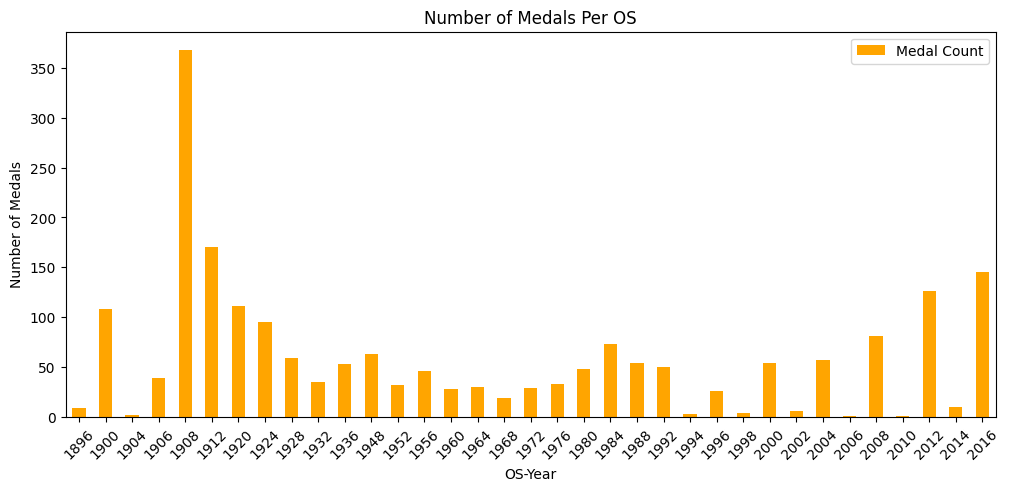

In [33]:
medals_per_year.plot(
    x='Year',
    y='Medal Count',
    kind='bar',
    figsize=(12,5),
    color='orange'
)

plt.title("Number of Medals Per OS")
plt.xlabel("OS-Year")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)

The bar chart shows how many medals **Great Britain** won in each Olympic Games. Each bar represents one OS-year, making it easy to compare individual Olympics side-by-side.
From the plot, we immediately notice that some years stand out with much higher medal counts—for example 1908, where Great Britain won unusually more than 350 medals.This is expected because the 1908 Olympics were held in London, and host nations usually compete in more events and have larger teams, leading to higher medal counts. The bar chart gives a clear snapshot of how medal numbers vary between separate Olympic Games.

Text(0, 0.5, 'Number of Medals')

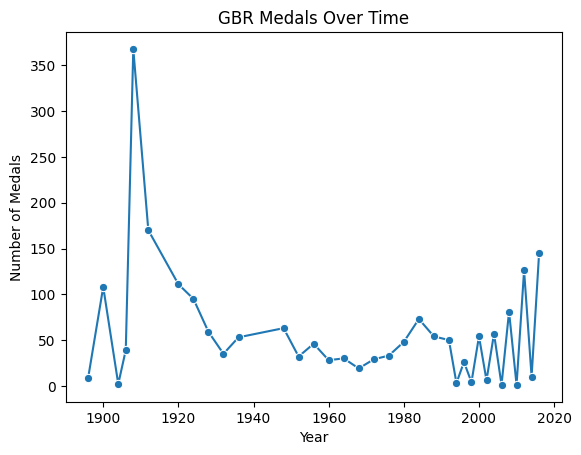

In [50]:
# Line plot of GBR medals over time
sns.lineplot(data=medals_per_year, x='Year', y='Medal Count', marker='o')
plt.title("GBR Medals Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Medals")

The plot shows the number of Olympic medals won by Great Britain over time. GBR’s medal count generally increases in recent years, with peaks in years of particularly strong performance, including a clear high peak in the year when London hosted the Olympics.

### ***Histogram for Ages***


Text(0, 0.5, 'Number of Athletes')

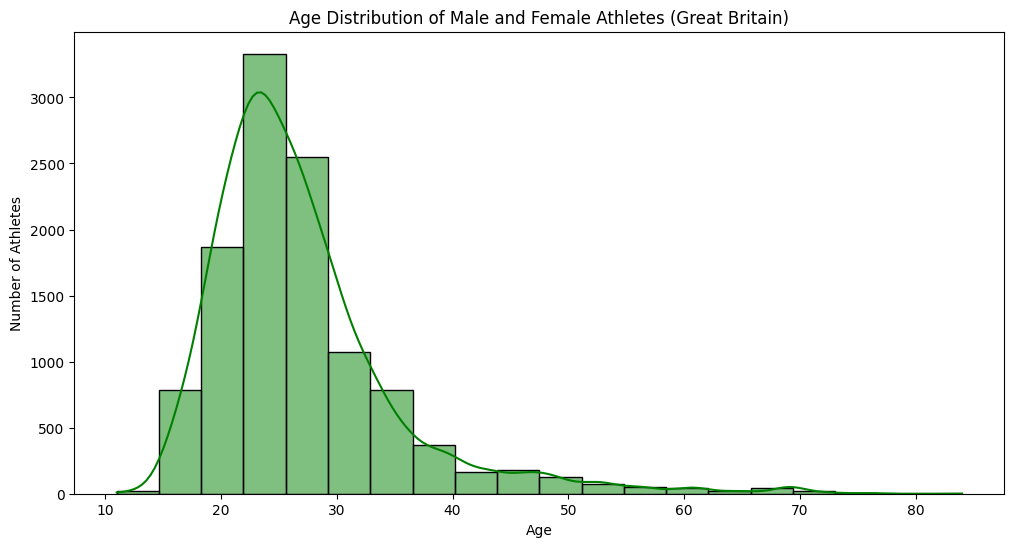

In [35]:
gbr_age = gbr['Age'].dropna() # filte age column 
plt.figure(figsize=(12,6))

sns.histplot(data=gbr_age , bins=20 ,
             kde= True , color= 'green')

plt.title("Age Distribution of Male and Female Athletes (Great Britain)")
plt.xlabel("Age")
plt.ylabel("Number of Athletes")


The age distribution of British Olympic athletes is **right-skewed**, which means most athletes are relatively young, and fewer athletes appear in the older age groups.This pattern reflects that physical peak performance occurs in early adulthood.
Some athletes above 30 appear in sports relying more on skill and experience.
Overall, the typical British Olympian competes in their early to mid-twenties.

In [24]:
age_statistic=gbr_age.agg(['mean', 'median', 'min', 'max', 'std'])
age_statistic

mean      26.925491
median    25.000000
min       11.000000
max       84.000000
std        8.232953
Name: Age, dtype: float64

Text(0.5, 1.0, 'Gender Distribution of GBR Athletes')

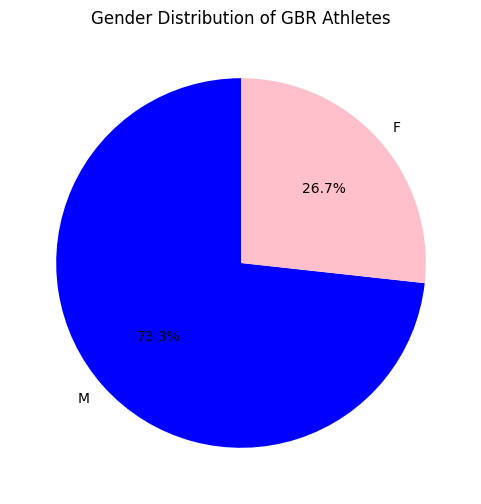

In [45]:
# Count number of male and female athletes
counts = gbr['Sex'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%',  # show percentage
    colors=['blue','pink'], 
    startangle=90
)
plt.title("Gender Distribution of GBR Athletes")



-------------------
------------------